In [1]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
from lightning.pytorch import seed_everything

seed_everything(12345)
scvi.settings.seed = 12345

c:\Users\tnfp1\anaconda3\envs\cellcharter\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\tnfp1\anaconda3\envs\cellcharter\Lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
c:\Users\tnfp1\anaconda3\envs\cellcharter\Lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
c:\Users\tnfp1\

In [2]:
import os
output_folder = r"C:/Users/tnfp1/banksy_py/sun/sample"

adata = sc.read_h5ad(os.path.join(output_folder, "testA1-2.h5ad"))

In [3]:
adata

AnnData object with n_obs × n_vars = 8695 × 95
    obs: 'region', 'instance', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_2_genes', 'pct_counts_in_top_5_genes', 'n_counts', 'shapeSize', 'leiden', 'portal_vein_EC45', 'LSEC45', 'LSEC Portal', 'LSEC Central', 'central_vein_EC45', 'stellateAll', 'stellate PeriPortal', 'stellate PeriCentral', 'FibroblastAll', 'fibroblastPortal', 'FibroblastsCentral', 'VSMC', 'capsular_fibroblasts45', 'Mesothelial cells', 'Hepatocytes', 'HepatocytesPortal', 'HepatocytesCentral', 'Cholangiocytes', 'cDC2s', 'Mig. cDCs', 'Neutrophils', 'Basophils', 'NK cells', 'ILC1s', 'T cells', 'pDCs', 'B cells', 'cDC1s', 'Kupffer cells', 'Capsule and Central Vein Mac', 'Portal LAM macrophages', 'Monocytes', 'LECs', 'Cleanliness', 'annotation', 'Hep', 'annotationSave', 'x', 'y'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 

In [4]:
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="raw_counts", 
    batch_key='region',
)

model = scvi.model.SCVI(adata)

In [5]:
model.train(early_stopping=True, enable_progress_bar=True)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 400/400: 100%|██████████| 400/400 [06:22<00:00,  1.12it/s, v_num=1, train_loss_step=49.2, train_loss_epoch=42.7]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [06:22<00:00,  1.05it/s, v_num=1, train_loss_step=49.2, train_loss_epoch=42.7]


In [6]:
adata.obsm['X_scVI'] = model.get_latent_representation(adata).astype(np.float32)

In [7]:
import numpy as np

if 'x' in adata.obs.columns and 'y' in adata.obs.columns:
    adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()
else:
    raise ValueError("x, y 좌표가 adata.obs에 없습니다.")


In [8]:
sq.gr.spatial_neighbors(adata, library_key=None, coord_type='generic', delaunay=True, spatial_key='spatial', percentile=99)

In [9]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_scVI', out_key='X_cellcharter', sample_key='region')

100%|██████████| 4/4 [00:00<00:00, 140.11it/s]


In [10]:
autok = cc.tl.ClusterAutoK(
    n_clusters=(7,15), 
    max_runs=10,
    convergence_tol=0.001
)

In [11]:
autok.fit(adata, use_rep='X_cellcharter')

Iteration 1/10


100%|██████████| 11/11 [00:28<00:00,  2.63s/it]


Iteration 2/10


100%|██████████| 11/11 [00:25<00:00,  2.33s/it]


Iteration 3/10


...

100%|██████████| 11/11 [00:28<00:00,  2.57s/it]


Iteration 9/10


100%|██████████| 11/11 [00:26<00:00,  2.40s/it]


Iteration 10/10


100%|██████████| 11/11 [00:24<00:00,  2.22s/it]


In [12]:
adata.obs['cluster_cellcharter'] = autok.predict(adata, use_rep='X_cellcharter')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


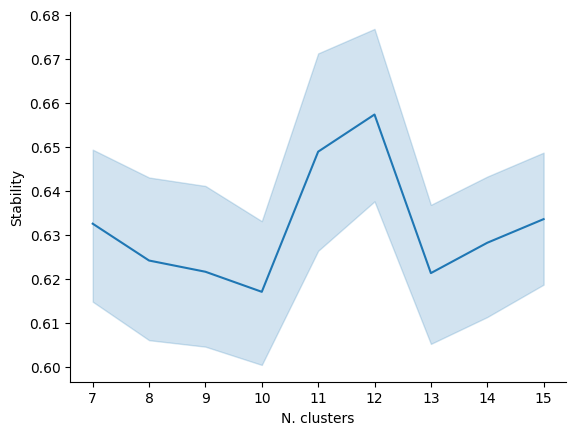

In [13]:
cc.pl.autok_stability(autok)

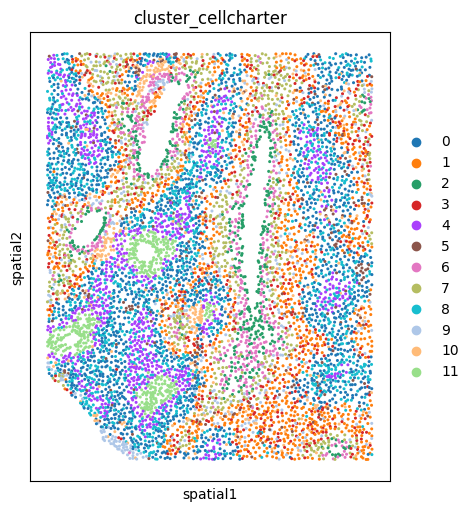

In [14]:
# 1. 좌표 설정 (이미 되어 있을 수도 있음)
adata.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy()

# 2. dummy 라이브러리 설정
adata.uns["spatial"] = {"dummy": {"images": {}}}
adata.obs["library_id"] = "dummy"

# 3. scatter plot (이미지 오버레이 제거)
sq.pl.spatial_scatter(
    adata,
    color=["cluster_cellcharter"],
    spatial_key="spatial",
    library_key=None,
    img=None,  # 이미지 오버레이 사용 안함
    size=40,
    figsize=(5,5)
)


In [15]:
adata

AnnData object with n_obs × n_vars = 8695 × 95
    obs: 'region', 'instance', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_2_genes', 'pct_counts_in_top_5_genes', 'n_counts', 'shapeSize', 'leiden', 'portal_vein_EC45', 'LSEC45', 'LSEC Portal', 'LSEC Central', 'central_vein_EC45', 'stellateAll', 'stellate PeriPortal', 'stellate PeriCentral', 'FibroblastAll', 'fibroblastPortal', 'FibroblastsCentral', 'VSMC', 'capsular_fibroblasts45', 'Mesothelial cells', 'Hepatocytes', 'HepatocytesPortal', 'HepatocytesCentral', 'Cholangiocytes', 'cDC2s', 'Mig. cDCs', 'Neutrophils', 'Basophils', 'NK cells', 'ILC1s', 'T cells', 'pDCs', 'B cells', 'cDC1s', 'Kupffer cells', 'Capsule and Central Vein Mac', 'Portal LAM macrophages', 'Monocytes', 'LECs', 'Cleanliness', 'annotation', 'Hep', 'annotationSave', 'x', 'y', '_scvi_batch', '_scvi_labels', 'cluster_cellcharter', 'library_id'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_d

In [16]:
adata1 = sc.read_h5ad(os.path.join(output_folder, "combinedresultA1-2.h5ad"))

In [17]:
import scanpy as sc

sc.pp.neighbors(adata, use_rep="X_cellcharter")
sc.tl.umap(adata)

In [18]:
adata1.obs['cellcharter'] = adata.obs['cluster_cellcharter']
adata1.obsm['X_cellcharter'] = adata.obsm['X_cellcharter']
adata1.obsm["cellcharter_umap"] = adata.obsm["X_umap"].copy()

In [19]:
adata1

AnnData object with n_obs × n_vars = 8695 × 95
    obs: 'region', 'instance', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_2_genes', 'pct_counts_in_top_5_genes', 'n_counts', 'shapeSize', 'leiden', 'portal_vein_EC45', 'LSEC45', 'LSEC Portal', 'LSEC Central', 'central_vein_EC45', 'stellateAll', 'stellate PeriPortal', 'stellate PeriCentral', 'FibroblastAll', 'fibroblastPortal', 'FibroblastsCentral', 'VSMC', 'capsular_fibroblasts45', 'Mesothelial cells', 'Hepatocytes', 'HepatocytesPortal', 'HepatocytesCentral', 'Cholangiocytes', 'cDC2s', 'Mig. cDCs', 'Neutrophils', 'Basophils', 'NK cells', 'ILC1s', 'T cells', 'pDCs', 'B cells', 'cDC1s', 'Kupffer cells', 'Capsule and Central Vein Mac', 'Portal LAM macrophages', 'Monocytes', 'LECs', 'Cleanliness', 'annotation', 'Hep', 'annotationSave', 'x', 'y', 'banksy_labels_nonspatial_pc20_nc0.00_r0.90', 'banksy_labels_scaled_gaussian_pc20_nc0.20_r0.90', 'banksy_labels_scaled_gaussian_pc20_nc0.50

In [20]:
adata1.obsm['X_cellcharter']

array([[ 0.3687523 , -1.282158  ,  0.18714811, ..., -0.6938143 ,
        -0.02881742,  1.0784961 ],
       [-0.7265932 , -0.28505477, -0.41055784, ...,  0.16091917,
         0.08582097, -0.6524025 ],
       [ 0.05654082,  1.1048197 ,  0.3698331 , ..., -0.04810508,
        -0.23931965,  1.1864805 ],
       ...,
       [-0.5584263 , -0.02323583, -1.0974538 , ..., -0.15178841,
         0.00615747,  0.78936356],
       [-0.71365   , -0.6761905 , -0.6024243 , ..., -0.18812609,
        -0.14216116,  0.6597679 ],
       [-0.89311147, -0.04208604,  0.2439222 , ..., -0.33043036,
         0.24808511, -0.40031603]], dtype=float32)

In [21]:
from matplotlib.cm import get_cmap
def plot_2d_embeddings_all(embedding, labels, ax,
                           method_str="UMAP", xlabel="UMAP 1", ylabel="UMAP 2",
                           cmap='tab20', pointsize=3,
                           show_legend=True, legend_loc='outside', label_fontsize=8):

    cmap_obj = get_cmap(cmap)
    label_ids = np.unique(labels)

    for i, label_id in enumerate(label_ids):
        mask = labels == label_id
        ax.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            c=[cmap_obj(i % 20)],
            s=pointsize,
            label=f"Cluster {label_id}",
            alpha=0.8
        )

    ax.set_title(f"{method_str}", fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axis('off')

    if show_legend:
        if legend_loc == 'outside':
            ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=label_fontsize)
        else:
            ax.legend(loc=legend_loc, fontsize=label_fontsize)

C:\Users\tnfp1\AppData\Local\Temp\ipykernel_26876\192138964.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = get_cmap(cmap)


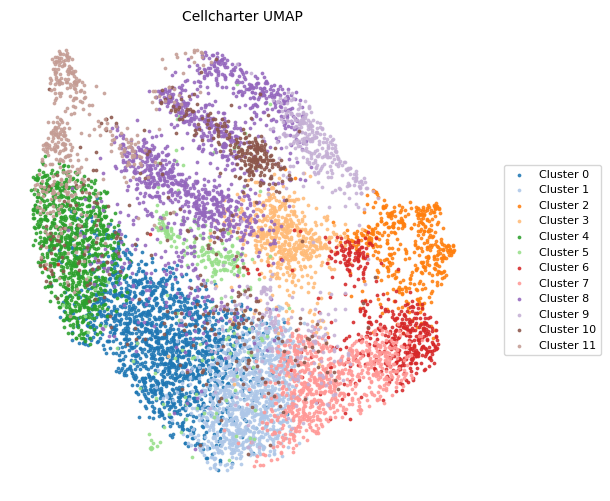

In [22]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_2d_embeddings_all(
    adata.obsm['X_umap'],
    adata.obs['cluster_cellcharter'].astype('int32'),
    ax=ax,
    method_str="Cellcharter UMAP",
    cmap='tab20'
)
plt.show()

In [ ]:
def plot_2d_embeddings_annotated(embedding, annotations, ax,
                                  method_str="UMAP", cmap='tab20',
                                  pointsize=3, label_fontsize=5,
                                  show_legend=True, legend_loc='outside',
                                  show_text=False):

    celltypes = adata.obs['annotation'].unique()
    cmap_obj = get_cmap(cmap)
    palette = {ct: cmap_obj(i % 20) for i, ct in enumerate(celltypes)}

    for ct in celltypes:
        mask = annotations == ct
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
            c=[palette[ct]] * np.sum(mask),
            s=pointsize,
            label=ct
        )


        if show_text:
            center_x = embedding[mask, 0].mean()
            center_y = embedding[mask, 1].mean()
            ax.text(center_x, center_y, ct,
                    fontsize=label_fontsize, weight='bold',
                    ha='center', va='center')

    ax.set_title(f'{method_str} with Cell Type Annotation')
    ax.axis('off')

    if show_legend:
        if legend_loc == 'outside':
            ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=label_fontsize)
        else:
            ax.legend(loc=legend_loc, fontsize=label_fontsize)

C:\Users\tnfp1\AppData\Local\Temp\ipykernel_26876\4091260869.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = get_cmap(cmap)


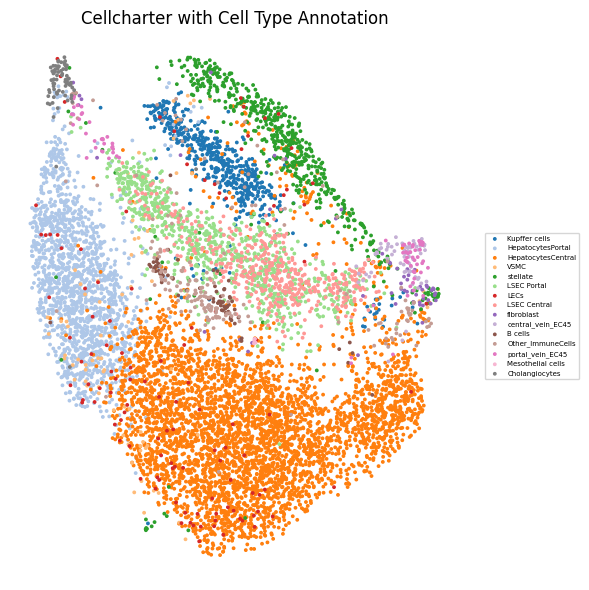

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_2d_embeddings_annotated(
    embedding=adata.obsm['X_umap'],
    annotations=adata.obs['annotation'].values,
    ax=ax,
    method_str="Cellcharter",
    cmap='tab20'
)
plt.tight_layout()
plt.show()


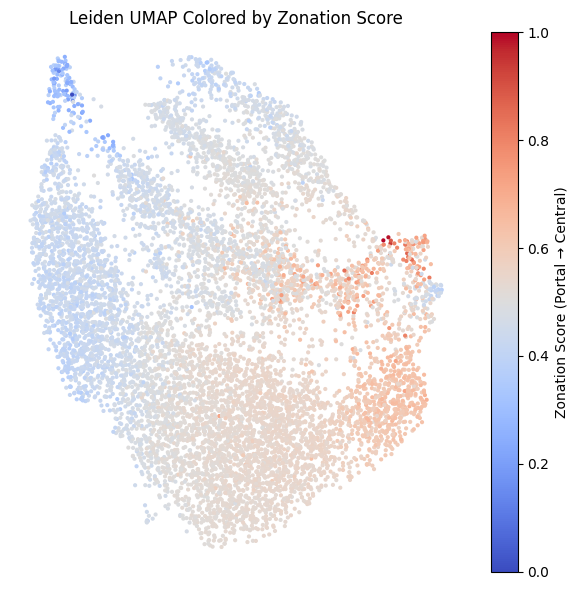

In [25]:
embedding = adata.obsm['X_umap']
norm = plt.Normalize(vmin=0, vmax=1)
cmap = plt.get_cmap('coolwarm')  # blue (portal) → red (central)

zonation_scores_per_cell = adata1.obs['zonation_score']

# Normalize zonation scores (min-max normalization)
min_score = np.min(zonation_scores_per_cell)
max_score = np.max(zonation_scores_per_cell)
if max_score > min_score:
    normalized_scores = (zonation_scores_per_cell - min_score) / (max_score - min_score)
else:
    normalized_scores = np.zeros_like(zonation_scores_per_cell)

fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=cmap(normalized_scores),
    s=4
)

ax.set_title('Leiden UMAP Colored by Zonation Score')
ax.axis('off')

# Add colorbar
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label('Zonation Score (Portal → Central)')

plt.tight_layout()
plt.show()


In [26]:
zonation_scores_per_cell = adata1.obs['zonation_score']

# Normalize zonation scores (min-max normalization)
min_score = np.min(zonation_scores_per_cell)
max_score = np.max(zonation_scores_per_cell)
if max_score > min_score:
    normalized_scores = (zonation_scores_per_cell - min_score) / (max_score - min_score)
else:
    normalized_scores = np.zeros_like(zonation_scores_per_cell)  # All same value

adata1.obs['normalized_scores'] = normalized_scores

    cluster  zonation_score_variance
0         0                 0.001616
1         1                 0.004534
2         2                 0.002374
3         3                 0.000795
4         4                 0.000702
5         5                 0.005255
6         6                 0.001584
7         8                 0.000738
8         9                 0.000482
9        10                 0.002372
10       12                 0.005694
11       13                 0.000934
12       14                 0.001315
13       15                 0.002788


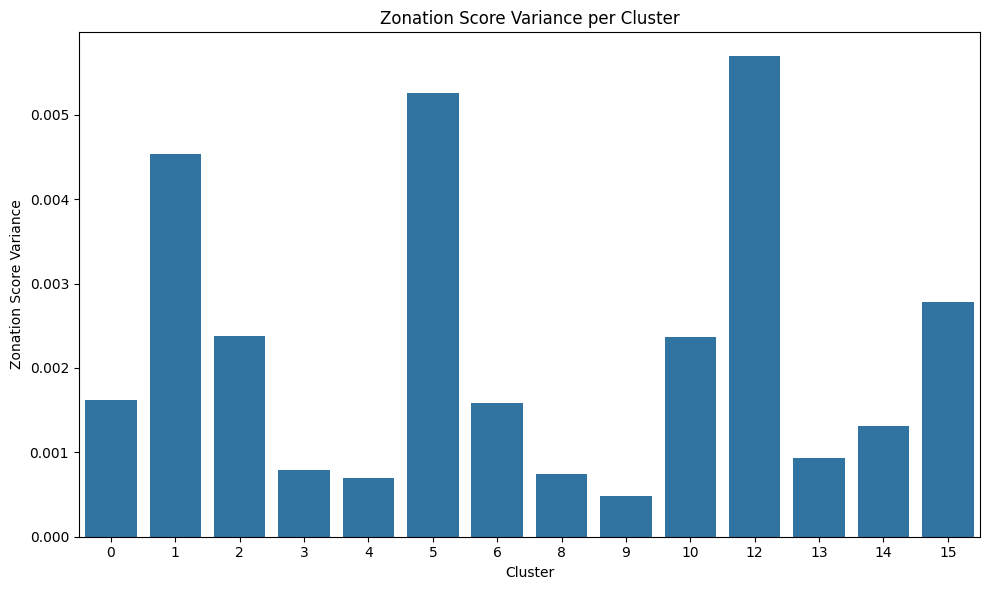

In [27]:
import seaborn as sns

cluster_labels = adata.obs['cluster_cellcharter']
zonation_score_per_cell = adata1.obs['normalized_scores']
adata.obs['cluster'] = cluster_labels

grouped = adata1.obs.groupby('cluster')['normalized_scores']
cluster_variances = grouped.var().reset_index()
cluster_variances.columns = ['cluster', 'zonation_score_variance']

print(cluster_variances)

plt.figure(figsize=(10, 6))
sns.barplot(data=cluster_variances, x='cluster', y='zonation_score_variance')
plt.xlabel("Cluster")
plt.ylabel("Zonation Score Variance")
plt.title("Zonation Score Variance per Cluster")
plt.xticks()
plt.tight_layout()
plt.show()


In [ ]:
def get_cluster_cell_counts(adata, cluster_col):
    cluster_counts = adata.obs[cluster_col].value_counts().sort_index()
    cluster_count_df = pd.DataFrame({
        'cluster_id': cluster_counts.index,
        'cell_count': cluster_counts.values
    }).reset_index(drop=True)
    return cluster_count_df

def calculate_total_zonation_variance(adata, zonation_score_col):
    zonation_scores = adata.obs[zonation_score_col].values
    total_variance = np.var(zonation_scores)
    return total_variance

def calculate_variance_based_purity(cluster_variances, cluster_counts, total_variance):
    cluster_variances = np.array(cluster_variances)
    cluster_counts = np.array(cluster_counts)
    total_cells = np.sum(cluster_counts)
    
    weighted_within_variance = np.sum(cluster_counts * cluster_variances)
    purity = 1 - (weighted_within_variance / (total_cells * total_variance))
    return purity

def calculate_cluster_variances(adata, cluster_col, zonation_score_col):
    cluster_labels = adata.obs[cluster_col].astype("int32")
    adata.obs['cluster'] = cluster_labels
    
    grouped = adata.obs.groupby('cluster')[zonation_score_col]
    cluster_variances_df = grouped.var().reset_index()
    cluster_variances_df.columns = ['cluster', 'zonation_score_variance']
    
    return cluster_variances_df

In [ ]:
cluster_col = 'cellcharter'
zonation_score_col = 'normalized_scores'

cluster_count_df = get_cluster_cell_counts(adata1, cluster_col)
cluster_counts = cluster_count_df['cell_count'].values

total_variance = calculate_total_zonation_variance(adata1, zonation_score_col)
print(f"Total zonation score variance: {total_variance:.4f}")

cluster_variances_df = calculate_cluster_variances(adata1, cluster_col, zonation_score_col)
cluster_variances = cluster_variances_df['zonation_score_variance'].values

purity = calculate_variance_based_purity(cluster_variances, cluster_counts, total_variance)
print(f"{cluster_col} variance-based purity: {purity:.4f}")


Total zonation score variance: 0.0045
cellcharter variance-based purity: 0.5680


In [30]:
adata1

AnnData object with n_obs × n_vars = 8695 × 95
    obs: 'region', 'instance', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_2_genes', 'pct_counts_in_top_5_genes', 'n_counts', 'shapeSize', 'leiden', 'portal_vein_EC45', 'LSEC45', 'LSEC Portal', 'LSEC Central', 'central_vein_EC45', 'stellateAll', 'stellate PeriPortal', 'stellate PeriCentral', 'FibroblastAll', 'fibroblastPortal', 'FibroblastsCentral', 'VSMC', 'capsular_fibroblasts45', 'Mesothelial cells', 'Hepatocytes', 'HepatocytesPortal', 'HepatocytesCentral', 'Cholangiocytes', 'cDC2s', 'Mig. cDCs', 'Neutrophils', 'Basophils', 'NK cells', 'ILC1s', 'T cells', 'pDCs', 'B cells', 'cDC1s', 'Kupffer cells', 'Capsule and Central Vein Mac', 'Portal LAM macrophages', 'Monocytes', 'LECs', 'Cleanliness', 'annotation', 'Hep', 'annotationSave', 'x', 'y', 'banksy_labels_nonspatial_pc20_nc0.00_r0.90', 'banksy_labels_scaled_gaussian_pc20_nc0.20_r0.90', 'banksy_labels_scaled_gaussian_pc20_nc0.50

In [31]:
adata1.write('C:/Users/tnfp1/banksy_py/sun/sample/combinedresultA1-2.h5ad')